In [1]:
import torch
import os.path
import argparse
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from utils import *
from PIL import Image
from datetime import datetime
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import train_test_split

In [2]:
transform = transforms.Compose([transforms.CenterCrop(128), transforms.ToTensor()])

trainset = datasets.ImageFolder(root='../../Datasets/CelebA/dataset/', transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=N, shuffle=False)

dataiter = iter(trainloader)
xtrain, _ = next(dataiter)
ytrain = np.load('../../Datasets/CelebA/dataset/attr.npy')  # labels with one-hot encoding
ytrain = torch.from_numpy(ytrain[:N, :]).float()

classes = ('_o_Clock_Shadow','Arched_Eyebrows','Attractive','Bags_Under_Eyes',
           'Bald','Bangs','Big_Lips','Big_Nose','Black_Hair','Blond_Hair','Blurry',
           'Brown_Hair','Bushy_Eyebrows','Chubby','Double_Chin','Eyeglasses','Goatee',
           'Gray_Hair','Heavy_Makeup','High_Cheekbones','Male','Mouth_Slightly_Open',
           'Mustache','Narrow_Eyes','No_Beard','Oval_Face','Pale_Skin','Pointy_Nose',
           'Receding_Hairline','Rosy_Cheeks','Sideburns','Smiling ','Straight_Hair','Wavy_Hair',
           'Wearing_Earrings','Wearing_Hat','Wearing_Lipstick','Wearing_Necklace','Wearing_Necktie','Young')

In [3]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

max_epochs = 1000

In [4]:
# def kPCA(X, Y):
#     nh1 = output1.size(0)
#     a = torch.mm(X, torch.t(X)) + torch.mm(Y, torch.t(Y))
#     oneN = torch.div(torch.ones(nh1, nh1), nh1).to(device)
#     a = a - torch.mm(oneN, a) - torch.mm(a, oneN) + torch.mm(torch.mm(oneN, a), oneN)   # centering
#     h, s, v = torch.linalg.svd(a, full_matrices=False)
#     return h[:, : h_dim], s

def kPCA(X, Y, eps=1e-6):
    # Kernel matrix
    a = X @ X.T + Y @ Y.T  # (B,B)
    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)
    return h, s

In [5]:
# Energy function
def my_loss(output1, X, output2, Y):
    h, s = kPCA(output1, output2)
    U = torch.mm(torch.t(output1), h)
    V = torch.mm(torch.t(output2), h)

    x_tilde = net3(torch.mm(h, torch.t(U)))
    y_tilde = net4(torch.mm(h, torch.t(V)))

    # cost
    f1 = torch.trace(torch.mm(torch.mm(output1, U), torch.t(h))) + torch.trace(torch.mm(torch.mm(output2, V), torch.t(h))) # Add third + of t.trace
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:h_dim]), torch.t(h))))
    f3 = 0.5 * ((torch.trace(torch.mm(torch.t(U), U))) + (torch.trace(torch.mm(torch.t(V), V))))
    recon_loss2 = torch.nn.MSELoss()
    recon_loss1 = torch.nn.MSELoss()
    f4 = recon_loss1(x_tilde.view(-1, 49152), X.view(-1, 49152)) + recon_loss2(y_tilde.view(-1, 40), Y.view(-1, 40))  # reconstruction loss

    loss = - f1 + f3 + f2 + 0.5 * (- f1 + f3 + f2) ** 2 + 100 * f4
    return loss

In [6]:
params = list(net1.parameters()) + list(net3.parameters()) + list(net2.parameters()) + list(net4.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=0)

l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost

In [7]:
while cost > 0.2 and t <= max_epochs:  # run epochs until convergence
    permutation = torch.randperm(xtrain.size()[0])
    avg_loss = 0
    for i in range(0, N, mb_size):
        indices = permutation[i:i + mb_size]
        datax = xtrain[indices, :, :, :].to(device)
        datay = ytrain[indices, :].to(device)
        output1, output2 = net1(datax), net2(datay)
        loss = my_loss(output1, datax, output2, datay)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.detach().cpu().numpy()
    cost = avg_loss

    # Remember lowest cost and save checkpoint
    is_best = cost < l_cost
    l_cost = min(cost, l_cost)
    dirs.save_checkpoint({
        'epochs': t + 1,
        'net1_state_dict': net1.state_dict(),
        'net3_state_dict': net3.state_dict(),
        'net2_state_dict': net2.state_dict(),
        'net4_state_dict': net4.state_dict(),
        'l_cost': l_cost,
        'optimizer': optimizer.state_dict()}, is_best)

    print(t, cost)
    t += 1
print('Finished Training. Lowest cost: {}'.format(l_cost))

1 548.7956
2 547.2211
3 545.6526
4 544.07275
5 542.4774
6 540.8019
7 539.0121
8 536.4998
9 531.5773
10 527.8287
11 524.20056
12 520.20087
13 517.9917
14 514.7598
15 512.0761
16 508.7904
17 513.5399
18 505.38943
19 503.32123
20 500.72626
21 498.17648
22 495.49158
23 492.7
24 490.062
25 487.27286
26 484.4989
27 481.65088
28 478.28296
29 475.33627
30 471.90366
31 468.35352
32 464.74136
33 460.5973
34 456.21414
35 452.04016
36 447.57062
37 442.28275
38 436.71667
39 431.13098
40 425.14072
41 418.89877
42 413.04492
43 405.94244
44 397.96744
45 390.79446
46 383.44235
47 375.35754
48 368.60315
49 360.40793
50 352.64813
51 344.95178
52 337.66217
53 330.57162
54 324.07098
55 319.67468
56 312.59448
57 305.1708
58 300.4437
59 294.5589
60 289.5031
61 284.62662
62 280.64502
63 276.61584
64 272.5593
65 268.70932
66 265.93756
67 262.5457
68 261.115
69 258.10953
70 254.6506
71 254.38768
72 249.82741
73 249.19696
74 245.97372
75 244.11722
76 242.46483
77 240.87177
78 238.98741
79 237.76556
80 236.0374
8

In [8]:
# Get latest model
if os.path.exists('cp/{}'.format(dirs.dircp)):
    sd_mdl = torch.load('cp/{}'.format(dirs.dircp))
    net1.load_state_dict(sd_mdl['net1_state_dict'])
    net3.load_state_dict(sd_mdl['net3_state_dict'])
    net2.load_state_dict(sd_mdl['net2_state_dict'])
    net4.load_state_dict(sd_mdl['net4_state_dict'])

output1 = net1(xtrain.to(device))
output2 = net2(ytrain.to(device))
h, s = kPCA(output1, output2)

U = torch.mm(torch.t(output1), h)
V = torch.mm(torch.t(output2), h)

In [9]:
# Save Model
torch.save({'net1': net1,
            'net3': net3,
            'net2': net2,
            'net4': net4,
            'net1_state_dict': net1.state_dict(),
            'net3_state_dict': net3.state_dict(),
            'net2_state_dict': net2.state_dict(),
            'net4_state_dict': net4.state_dict(),
            'xtrain': xtrain,
            'ytrain': ytrain,
            'classes': classes,
            'h': h, 'N': N, 's': s, 'U': U, 'V': V}, 'out/{}'.format(dirs.dirout))

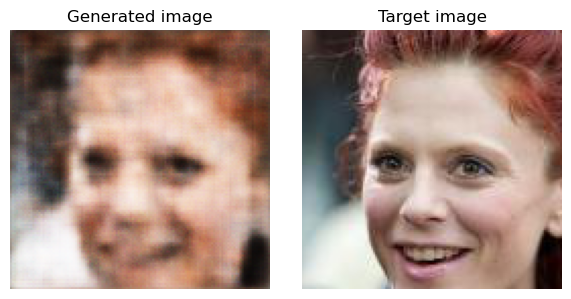

Bags_Under_Eyes
Big_Nose
Brown_Hair
High_Cheekbones
Mouth_Slightly_Open
No_Beard
Smiling 
Young


In [10]:
target_index = 1

h_target = h[target_index, :]
# make tensor [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  
# h_target = torch.zeros(opt.h_dim).double().to(opt.device)
# h_target[1] = 1.0

# x_gen = net3(torch.mv(U, h_target)).detach().cpu().numpy().reshape(28, 28)
z = torch.mv(U, h_target)          # [z_dim]
z = z.unsqueeze(0)                 # [1, z_dim]  <-- add batch dim

x_gen = net3(z).detach().cpu().numpy()
x_gen = x_gen.reshape(3, 128, 128).transpose(1, 2, 0)

y_gen = net4(torch.mv(V, h_target)).detach().cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].imshow(x_gen)
ax[0].set_title('Generated image')
ax[0].axis('off')

ax[1].imshow(xtrain[target_index].numpy().transpose(1, 2, 0))
ax[1].set_title('Target image')
ax[1].axis('off')

plt.tight_layout()
plt.show()

for i, l in enumerate(y_gen):
    if l > 0:
        print(classes[i])